In [ ]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
online_retail = fetch_ucirepo(id=352) 
  
# data (as pandas dataframes) 
X = online_retail.data.features 
y = online_retail.data.targets 
  
# metadata 
print(online_retail.metadata) 
  
# variable information 
print(online_retail.variables) 


{'uci_id': 352, 'name': 'Online Retail', 'repository_url': 'https://archive.ics.uci.edu/dataset/352/online+retail', 'data_url': 'https://archive.ics.uci.edu/static/public/352/data.csv', 'abstract': 'This is a transactional data set which contains all the transactions occurring between 01/12/2010 and 09/12/2011 for a UK-based and registered non-store online retail.', 'area': 'Business', 'tasks': ['Classification', 'Clustering'], 'characteristics': ['Multivariate', 'Sequential', 'Time-Series'], 'num_instances': 541909, 'num_features': 6, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': None, 'index_col': ['InvoiceNo', 'StockCode'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2015, 'last_updated': 'Mon Oct 21 2024', 'dataset_doi': '10.24432/C5BW33', 'creators': ['Daqing Chen'], 'intro_paper': {'ID': 361, 'type': 'NATIVE', 'title': 'Data mining for the online retail industry: A case study of RFM model-based customer segmenta

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_excel('../data/raw/Online Retail.xlsx')

# First look
print(df.shape)
print(df.dtypes)
df.head()

(541909, 8)
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
dtype: object


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
# Check missing values
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [4]:
# Remove nulls and returns (negative quantities)
df = df.dropna(subset=['CustomerID'])
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

print(f"Clean dataset: {df.shape[0]} rows")

Clean dataset: 397884 rows


In [5]:
# Create Revenue column
df['Revenue'] = df['Quantity'] * df['UnitPrice']
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# RFM reference date
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

# Calculate RFM
rfm = df.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('Revenue', 'sum')
).reset_index()

rfm.head(10)

,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40
5,12352.0,36,8,2506.04
6,12353.0,204,1,89.00
7,12354.0,232,1,1079.40
8,12355.0,214,1,459.40
9,12356.0,23,3,2811.43


In [6]:
from sklearn.preprocessing import StandardScaler

# Scale RFM values
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

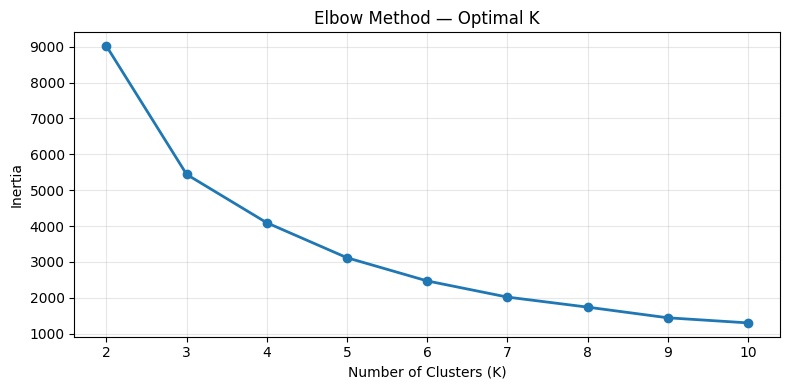

In [7]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, marker='o', linewidth=2)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method — Optimal K')
plt.xticks(K_range)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/figures/elbow_method.png', dpi=150)
plt.show()

In [8]:
# Use K=4 (adjust based on your elbow plot)
k_optimal = 4

km_final = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
rfm['Cluster'] = km_final.fit_predict(rfm_scaled)

# Cluster summary
cluster_summary = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(1)
cluster_summary['Count'] = rfm.groupby('Cluster')['CustomerID'].count()
print(cluster_summary)

         Recency  Frequency  Monetary  Count
Cluster                                     
0           43.7        3.7    1359.0   3054
1          248.1        1.6     480.6   1067
2            7.4       82.5  127338.3     13
3           15.5       22.3   12709.1    204


C:\Users\Usuario\AppData\Local\Temp\ipykernel_16964\1664015769.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=rfm, x='Cluster', y=metric, ax=ax, palette='Set2')
C:\Users\Usuario\AppData\Local\Temp\ipykernel_16964\1664015769.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=rfm, x='Cluster', y=metric, ax=ax, palette='Set2')
C:\Users\Usuario\AppData\Local\Temp\ipykernel_16964\1664015769.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=rfm, x='Cluster', y=metric, ax=ax, palette='Set2')


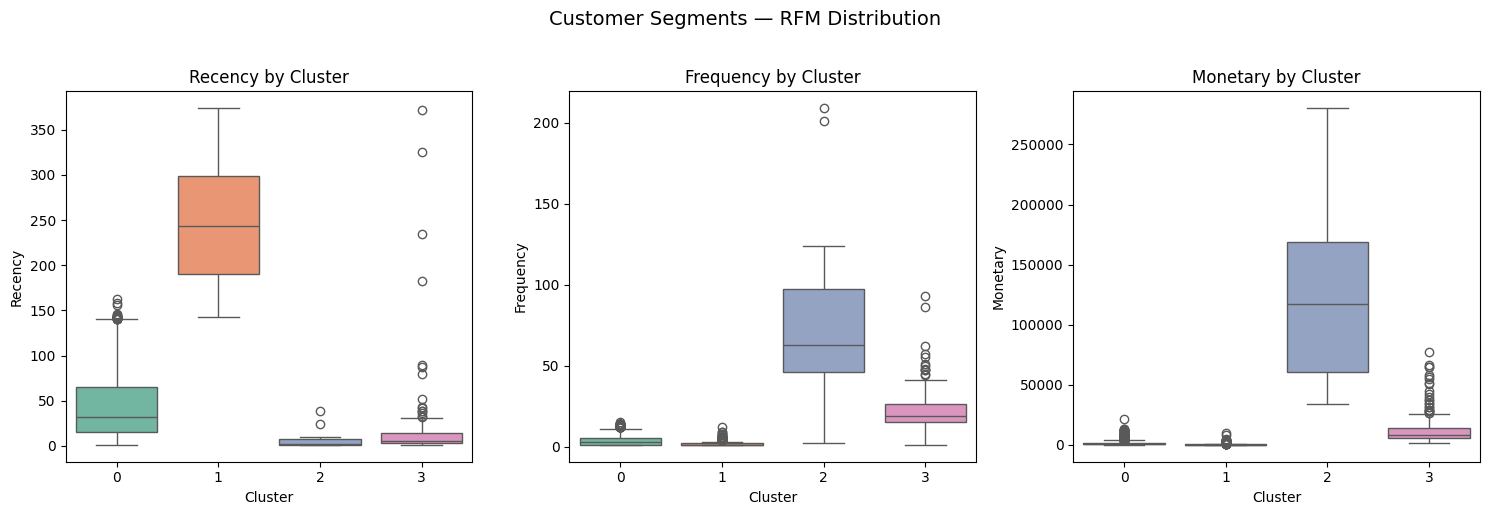

In [9]:
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = ['Recency', 'Frequency', 'Monetary']
for ax, metric in zip(axes, metrics):
    sns.boxplot(data=rfm, x='Cluster', y=metric, ax=ax, palette='Set2')
    ax.set_title(f'{metric} by Cluster')
    ax.set_xlabel('Cluster')

plt.suptitle('Customer Segments — RFM Distribution', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../reports/figures/rfm_clusters.png', dpi=150)
plt.show()

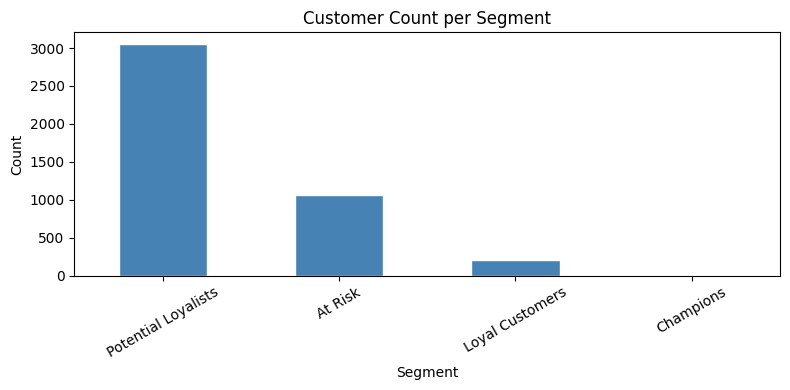

In [11]:
# After seeing cluster_summary, assign business labels
segment_labels = {
    2: 'Champions',
    3: 'Loyal Customers',
    0: 'Potential Loyalists',
    1: 'At Risk'
}

rfm['Segment'] = rfm['Cluster'].map(segment_labels)

# Segment size
rfm['Segment'].value_counts().plot(kind='bar', figsize=(8,4), color='steelblue', edgecolor='white')
plt.title('Customer Count per Segment')
plt.xlabel('Segment')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('../reports/figures/segment_distribution.png', dpi=150)
plt.show()

In [ ]:
import plotly.express as px

# Scatter 3D 
fig = px.scatter_3d(
    rfm,
    x='Recency', y='Frequency', z='Monetary',
    color='Segment',
    hover_data=['CustomerID'],
    title='Customer Segmentation — RFM 3D View',
    color_discrete_map={
        'Champions': '#FFD700',
        'Loyal Customers': '#2ECC71',
        'Potential Loyalists': '#3498DB',
        'At Risk': '#E74C3C'
    }
)
fig.write_html('../reports/figures/rfm_3d_segments.html')
fig.show()

In [ ]:
# Pie chart distribution
fig2 = px.pie(
    rfm,
    names='Segment',
    title='Customer Segment Distribution',
    color_discrete_map={
        'Champions': '#FFD700',
        'Loyal Customers': '#2ECC71',
        'Potential Loyalists': '#3498DB',
        'At Risk': '#E74C3C'
    }
)
fig2.write_html('../reports/figures/segment_pie.html')
fig2.show()